## Import

In [1]:
from utils import *
from sklearn.model_selection import train_test_split
import tensorflow as tf
print(tf.__version__)

Traning models ...
2.21.0


## Parameters

In [2]:
target_column = "AMZN"
input_days= 30
output_days= [1]
test_size=0.2
shuffle=True

## Load dataset

In [3]:
data = read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Load data completed.
Make sure date items are datetime


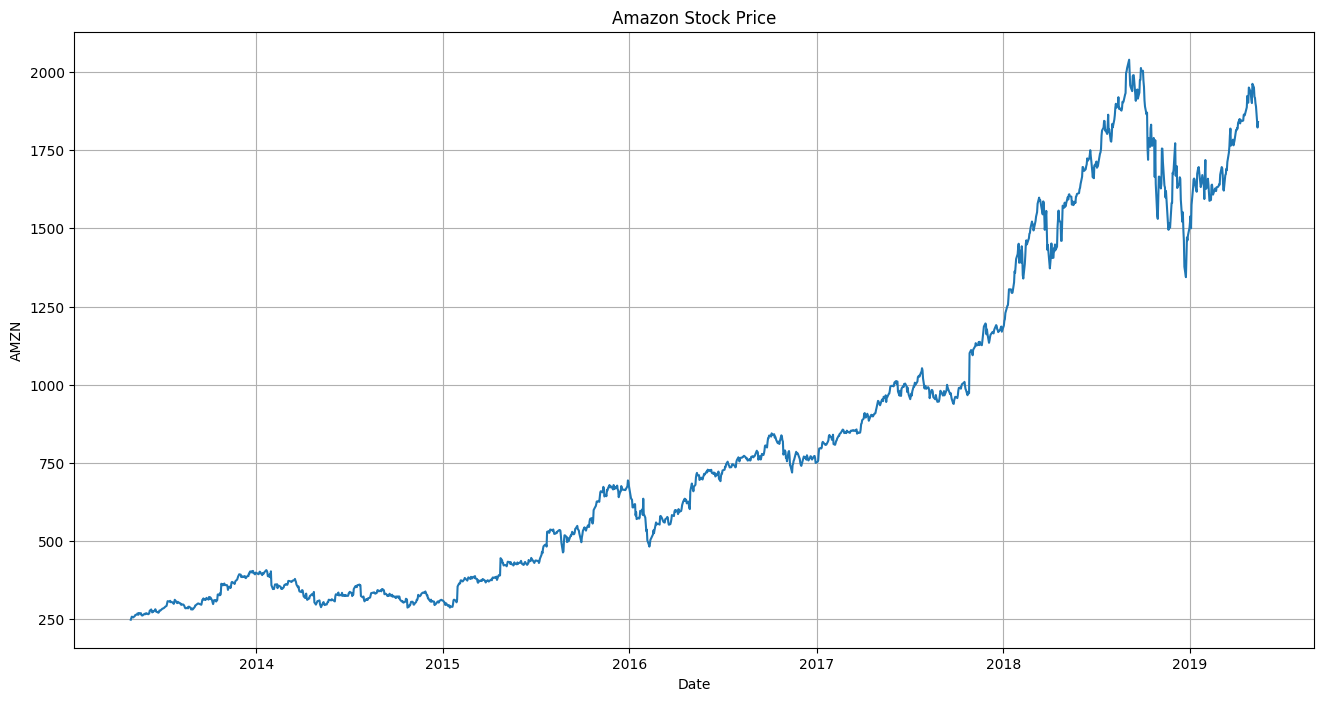

In [4]:
plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [5]:
selected_value = data[target_column].values
window_data = {}
for item in output_days:
    X, y = generate_sliding_windows(
        selected_value,
        input_days,
        item
        )
    window_data[item] = {
        "X" : X,
        "y" : y
    }


 Expected generated data length should be: 1490
x_start_index: 0 - x_end_index: 29 - y_start_index: 30 - y_end_index: 31
x_start_index: 1 - x_end_index: 30 - y_start_index: 31 - y_end_index: 32
x_start_index: 2 - x_end_index: 31 - y_start_index: 32 - y_end_index: 33
x_start_index: 3 - x_end_index: 32 - y_start_index: 33 - y_end_index: 34
x_start_index: 4 - x_end_index: 33 - y_start_index: 34 - y_end_index: 35
x_start_index: 5 - x_end_index: 34 - y_start_index: 35 - y_end_index: 36
x_start_index: 6 - x_end_index: 35 - y_start_index: 36 - y_end_index: 37
x_start_index: 7 - x_end_index: 36 - y_start_index: 37 - y_end_index: 38
x_start_index: 8 - x_end_index: 37 - y_start_index: 38 - y_end_index: 39


In [6]:
# window_output[1]["X"]

### Train / Test Split

In [7]:
train_test_data = {}

for day in output_days:
    X = window_data[day]["X"]
    y = window_data[day]["y"]

    X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size= test_size,
            shuffle= shuffle
        )
    train_test_data[day] = {
            "X_train" : X_train,
            "X_test" : X_test,
            "y_train" : y_train,
            "y_test" : y_test
            }

In [8]:
# print(train_test_data)
# print(train_test_data.keys)
# print(output_days)

### Data Scaling

In [9]:
scaled_data = {}
print("Start")
for day in train_test_data:
    
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, target_scaler = scale_data(
        train_test_data[day]["X_train"],
        train_test_data[day]["X_test"],
        train_test_data[day]["y_train"],
        train_test_data[day]["y_test"]
    )
    print(f"day- {day}")
    print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
    print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

    scaled_data[day] = {
        "X_train_norm" : X_train_norm,
        "X_test_norm" : X_test_norm,
        "y_train_norm" : y_train_norm,
        "y_test_norm" : y_test_norm,
        "target_scaler" : target_scaler
        }
    # print(scaled_data[day]["X_train_norm"])
    # print(scaled_data[day]["y_train_norm"])

Start
day- 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)


### Training Regression Models

#### Dense Deep Network

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
dense_model = Sequential()
dense_model.add(Dense(32, input_shape=(30,), activation="relu"))
dense_model.add(Dense(64, activation="relu"))
dense_model.add(Dense(128, activation="relu"))
dense_model.add(Dense(64, activation="relu"))
dense_model.add(Dense(32, activation="relu"))
dense_model.add(Dense(10))



dense_model.summary()

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,090 (86.29 KB)

 Trainable params: 22,090 (86.29 KB)

 Non-trainable params: 0 (0.00 B)